# Lab 2: Image Enhancement and Filtering Techniques - Spatial Domain
`By: Raman Shakya (022bscit033)`

In [75]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [76]:
img = cv2.imread('wow.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = cv2.resize(img, (256, 256))

In [77]:
def plot(rows, cols, images, titles):
    plt.figure(figsize=(10,10))
    for i in range(rows):
        for j in range(cols):
            plt.subplot(rows, cols, i * cols + j + 1)
            plt.imshow(images[i*cols+j], cmap='gray')
            plt.title(titles[i*cols+j])

## Contrast Stretching, Thresholding, Digital Negative and Intensity Level Slicing

In [78]:
def contrast_stretching(img, x1, y1, x2, y2):
    output = []
    for row in img:
        temp = []
        for pix in row:
            if pix < x1:
                slope = y1/x1
                temp.append(slope*pix)
            elif pix < x2:
                slope = (y2-y1)/(x2-x1)
                temp.append((pix-x1)*slope + y1)
            else:
                slope = (256-y2)/(256-x2)
                temp.append((pix-x2)*slope + y2)
        output.append(temp)
    return np.array(output)

In [79]:
def thresholding(img, threshold):
    output=[]
    for row in img:
        temp = []
        for pix in row:
            if pix > threshold: 
                temp.append(255)
            else:
                temp.append(0)
        output.append(temp)
    return np.array(output)

In [80]:
def digitalNegative(img):
    output=[]
    for row in img:
        temp = []
        for pix in row:
            temp.append(255-pix)
        output.append(temp)
    return np.array(output)

In [81]:
def intensityLevelSlicing(img, lvl1, lvl2):
    output=[]
    for row in img:
        temp = []
        for pix in row:
            if pix > lvl1 and pix < lvl2:
                temp.append(256)
            else: 
                temp.append(pix)
        output.append(temp)
    return np.array(output)

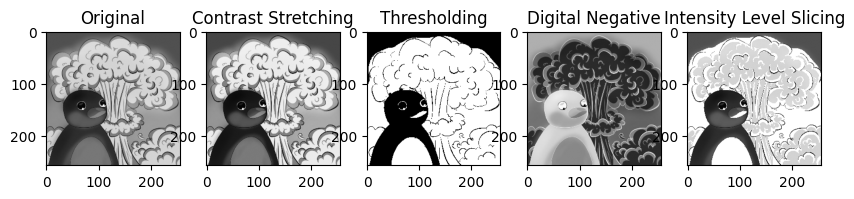

In [82]:
plot(1,5, [img, contrast_stretching(img, 50, 30, 200, 230), thresholding(img, 100), digitalNegative(img), intensityLevelSlicing(img, 100, 200)],
    ["Original", "Contrast Stretching", "Thresholding", "Digital Negative", "Intensity Level Slicing"])

## Histogram ( calculate, equalize )

In [83]:
def getHistogram(img):
    hist = [0 for i in range(256)]
    for row in img:
        for pix in row:
            hist[pix]+=1
    return hist

In [84]:
def histogramEqualization(img, histogram):
    left_end = 0
    while histogram[left_end]==0: left_end+=1
    right_end = 255
    while histogram[right_end]==0: right_end-=1

    histogramMap1 = [0 for _ in range(256)]
    histogram1 = [0 for _ in range(256)]
    for i in range(left_end, right_end):
        temp_ind = int(255 / (right_end - left_end) * (i - left_end))
        histogramMap1[i] = temp_ind
        histogram1[temp_ind] += histogram[i]


    # equalization
    previous = 0
    totalPixels = len(img) * len(img[0])

    histogramMap2 = [0 for _ in range(256)]
    for i,j in enumerate(histogram1):
        previous += j / totalPixels
        histogramMap2[i] = round(previous * 255)

    output = []
    for i in range(len(img)):
        temp = []
        for j in range(len(img[0])):
            temp.append(histogramMap2[histogramMap1[int(img[i][j])]])
        output.append(temp)


    return np.array(output)

Text(0.5, 1.0, 'equalized histogram')

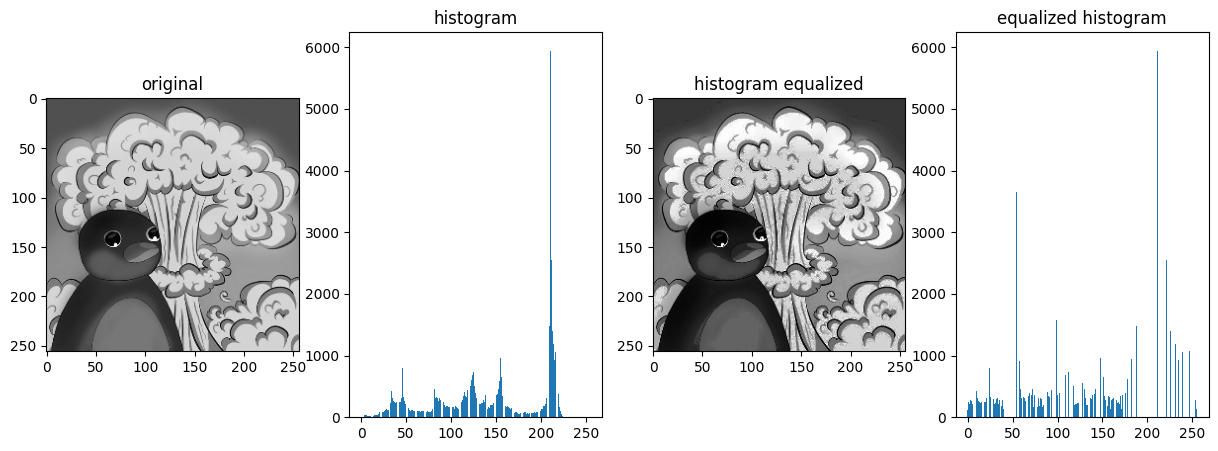

In [85]:
plt.figure(figsize=(15,5))
plt.subplot(141)
plt.imshow(img, cmap='gray')
plt.title("original")
originalHistogram = getHistogram(img)

plt.subplot(142)
plt.bar(range(256), originalHistogram)
plt.title("histogram")

equalized = histogramEqualization(img, originalHistogram)
plt.subplot(143)
plt.imshow(equalized, cmap='gray')
plt.title("histogram equalized")

equalizedHist = getHistogram(equalized)
plt.subplot(144)
plt.bar(range(256), equalizedHist)
plt.title("equalized histogram")


# Smoothing Spatial Filters


In [86]:
def kernelFilter(img, kernel):
    padImg = np.pad(img, 1)
    output = []
    for i in range(1, len(img)):
        temp = []
        for j in range(1, len(img[0])):
            temp.append(np.clip(np.sum(padImg[i-1:i+2, j-1:j+2]*kernel), 0, 255))
        output.append(temp)
    return np.array(output)

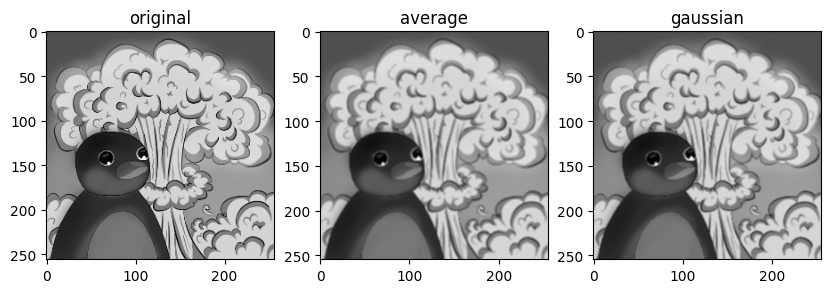

In [87]:
average  = kernelFilter(img, np.ones((3,3), dtype=np.uint8)/9)
gaussian = kernelFilter(img, np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
])/16)
plot (1, 3, [img, average, gaussian], ['original', 'average', 'gaussian'])

# Sharpening Filters

In [88]:
def laplacianFilter(img):
    return kernelFilter(img, np.array([
        [0, 1, 0],
        [1, -4, 1],
        [0, 1, 0]
    ]))

In [89]:
def edgeDetection(img, kernelX, kernelY):
    magnitude = []
    total = 0
    for i in range(1, len(img)-2):
        temp = []
        for j in range(1, len(img[0])-2):
            tempx = sum(sum(kernelX * img[i-1:i+2, j-1:j+2]))
            tempy = sum(sum(kernelY * img[i-1:i+2, j-1:j+2]))
            temp_mag = ((tempx)**2 + (tempy)**2) ** .5
            total += temp_mag
            temp.append(temp_mag)
        magnitude.append(temp)

    threshold = total / (len(magnitude) * len(magnitude[0]))

    for i in range(len(magnitude)):
        for j in range(len(magnitude[0])):
            if magnitude[i][j] > threshold: magnitude[i][j] = 255
            else:
                magnitude[i][j] = 0
    return np.array(magnitude)


In [90]:
def prewittFilter(img):
    return edgeDetection(img, np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1],
    ]), np.array([
        [-1, -1, -1],
        [0, 0, 0],
        [1, 1, 1]
    ]))


In [91]:
def sobelFilter(img):
    return edgeDetection(img, np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1],
    ]), np.array([
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1]
    ]))

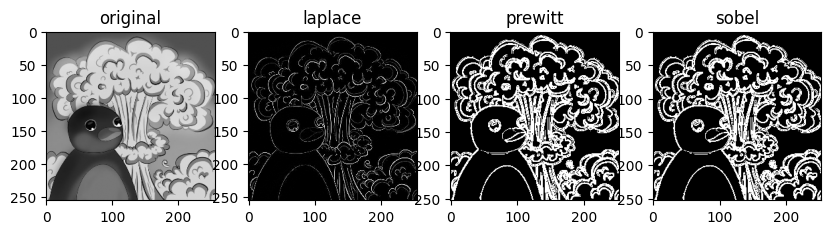

In [92]:
laplace  = laplacianFilter(img)
prewitt  = prewittFilter(img)
sobel = sobelFilter(img)

plot(1,4, [img, laplace, prewitt, sobel], ["original", "laplace", "prewitt", "sobel"])

# Image Magnification ( replication and interpolation )
> needs update

In [93]:
def circle(x, y, r, h, k):
    distance = np.sqrt((x-h)**2 + (y-k)**2)
    if distance < r: return 255 - distance / r * 255
    return 0

def createCircle(w=128, h=128):
    img = np.zeros((w, h), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            img[i, j] = circle(i, j, h//3, w//2, h//2)
    return img

In [94]:
def replication(img):
    output = np.zeros((len(img)*2, len(img[0])*2), dtype=np.uint8)
    for i in range(len(img)):
        for j in range(len(img[0])):
            output[i*2:i*2+2, j*2:j*2+2] = img[i, j]
    return output

In [95]:
def interpolate(img):
    output = np.zeros((len(img)*2, len(img[0])*2), dtype=np.uint8)
    for i in range(len(img)):
        for j in range(len(img[0])):
            output[i*2, j*2] = img[i, j]
        for j in range(1, len(output[0])-1, 2):
            output[i*2, j] = int(output[i*2, j-1]/2 + output[i*2,j+1]/2)
        output[i*2, len(img[0])*2-1] = output[i*2, len(img[0])*2-2] // 2
    
    for i in range(1, len(output), 2):
        for j in range(len(output[0])):
            if i+1 == len(output):
                output[i, j] = output[i-1, j] // 2
            else:
                output[i, j] = int(output[i-1, j]/2 + output[i+1, j]/ 2)
    return output

Text(0.5, 1.0, 'interpolated')

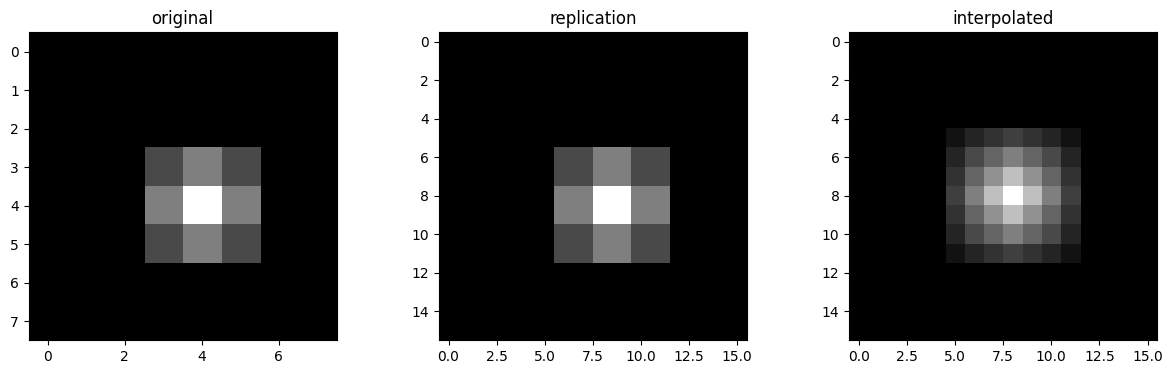

In [96]:
img = createCircle(8, 8)
replicated  = replication(img)
interpolated = interpolate(img)

plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title('original')

plt.subplot(132)
plt.imshow(replicated, cmap='gray')
plt.title('replication')

plt.subplot(133)
plt.imshow(interpolated, cmap='gray')
plt.title('interpolated')
